# Irene Pipeline – Step-by-Step Walkthrough

This notebook walks through every processing stage applied inside `irene.py`
on a single event and a single fiber channel, plotting the waveform after each step:

1. **Raw waveforms** – what comes out of the DAQ
2. **Baseline subtraction** – remove per-sensor pedestal (`baseline_subtractor`)
3. **Fourier (low-pass) filter** – remove high-frequency noise (`fourier_filter`)
4. **Calibration** – convert ADC counts to photo-electrons and apply MAW
   (`calibrate_fibers_hg` / `calibrate_fibers_lg`) + **summed waveforms**
5. **Zero suppression** – find samples above threshold; highlight S1/S2 windows
   (`zero_suppress_wfs_hg` / `zero_suppress_wfs_lg`)
6. **PMAP selection** – get the pmap and explain the acception/rejections of S1 and S2

In [1]:
import sys
import os

# Make sure the IC package is importable when running from the nb/ folder
IC_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if IC_ROOT not in sys.path:
    sys.path.insert(0, IC_ROOT)

import numpy  as np
import tables as tb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# IC processing functions (same ones used in irene.py)
from invisible_cities.cities.components import baseline_subtractor
from invisible_cities.cities.components import fourier_filter
from invisible_cities.cities.components import calibrate_fibers_hg
from invisible_cities.cities.components import calibrate_fibers_lg
from invisible_cities.cities.components import zero_suppress_wfs_hg
from invisible_cities.cities.components import zero_suppress_wfs_lg

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})

## Configuration
Mirrors the parameters found in `irene.conf` and used in `irene.py`.

In [35]:
# ── Data file ──────────────────────────────────────────────────────────────
RUN_NUMBER   = 1128
DATA_FILE    = f"{IC_ROOT}/data/run_{RUN_NUMBER}_0000_ldc1_trg0.waveforms.h5"
DETECTOR_DB  = 'hddemojb'

# ── Event / channel to inspect ─────────────────────────────────────────────
EVENT_IDX    = 12    # index inside the file (not the event number)
FIBER_CH     = 4    # fiber channel index to plot

# ── irene processing parameters ────────────────────────────────────────────
N_BASELINE           = 2800   # samples used to compute the pedestal
N_MAW_S1             = 10     # MAW window for HG (S1 search)
N_MAW_S2             = 100    # MAW window for LG (S2 search)
FIBER_SAMP_WID       = 25.0   # sampling width in ns
FIBER_CUTOFF_FREQ_MHZ = 3.0   # Fourier low-pass cut-off in MHz
THR_CSUM_S1          = 100.0  # zero-suppression threshold on HG sum (pes)
THR_CSUM_S2          = 60.0   # zero-suppression threshold on LG sum (pes)

## Load raw waveforms
Open the HDF5 file and extract **all fiber channels for one event**.
The shapes are `(n_fibers, n_samples)` – exactly what irene receives per event.

In [36]:
with tb.open_file(DATA_FILE, 'r') as h5in:
    # shape: (n_events, n_fibers, n_samples)  →  slice one event
    fiber_hg_all = h5in.root.RD.fiberrwf_hg[:]
    fiber_lg_all = h5in.root.RD.fiberrwf_lg[:]
    event_info   = h5in.root.Run.events[:]

# Pick a single event  →  shape (n_fibers, n_samples)
fiber_hg_raw = fiber_hg_all[EVENT_IDX]
fiber_lg_raw = fiber_lg_all[EVENT_IDX]

event_number = event_info[EVENT_IDX][0]
n_fibers, n_samples = fiber_hg_raw.shape

print(f"Event index {EVENT_IDX}  →  event number {event_number}")
print(f"Shape per event: {n_fibers} fibers × {n_samples} samples")
print(f"Total time window: {n_samples * FIBER_SAMP_WID * 1e-3:.1f} µs")

# Convenience time axis in µs
t_us = np.arange(n_samples) * FIBER_SAMP_WID * 1e-3

Event index 12  →  event number 13
Shape per event: 36 fibers × 14000 samples
Total time window: 350.0 µs


---
## Step 1 – Raw waveforms
The ADC samples straight from the digitiser.
Negative polarity is normal: the signal goes *down* in raw ADC counts.

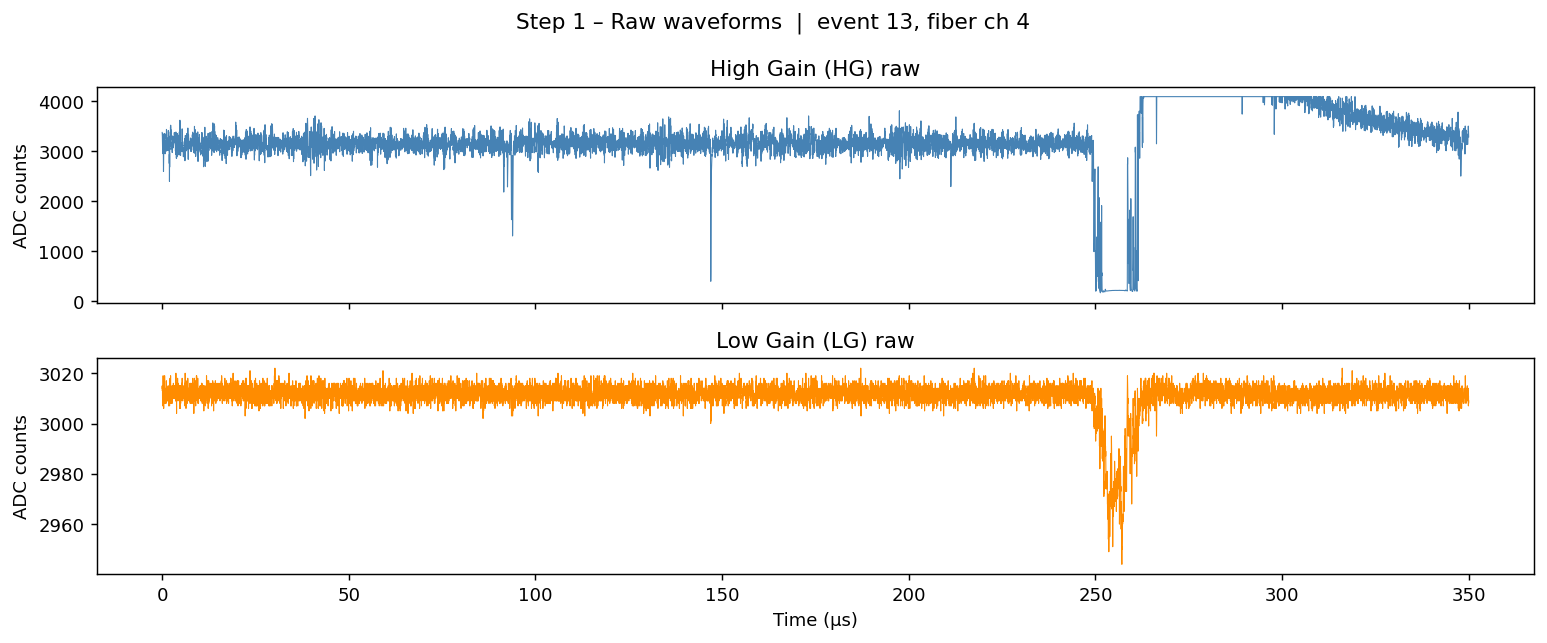

HG baseline region mean (first 2800 samples): 3148.8 ADC
LG baseline region mean (first 2800 samples): 3012.0 ADC


In [37]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
fig.suptitle(f'Step 1 – Raw waveforms  |  event {event_number}, fiber ch {FIBER_CH}')

axes[0].plot(t_us, fiber_hg_raw[FIBER_CH], lw=0.6, color='steelblue')
axes[0].set_ylabel('ADC counts')
axes[0].set_title('High Gain (HG) raw')

axes[1].plot(t_us, fiber_lg_raw[FIBER_CH], lw=0.6, color='darkorange')
axes[1].set_ylabel('ADC counts')
axes[1].set_xlabel('Time (µs)')
axes[1].set_title('Low Gain (LG) raw')

plt.tight_layout()
plt.show()

print(f"HG baseline region mean (first {N_BASELINE} samples): {fiber_hg_raw[FIBER_CH, :N_BASELINE].mean():.1f} ADC")
print(f"LG baseline region mean (first {N_BASELINE} samples): {fiber_lg_raw[FIBER_CH, :N_BASELINE].mean():.1f} ADC")

---
## Step 2 – Baseline subtraction
```python
# irene.py
fiber_hg_rwf_to_bswf = fl.map(baseline_subtractor(n_baseline), args='fiber_hg', out='bsfiber_hg')
fiber_lg_rwf_to_bswf = fl.map(baseline_subtractor(n_baseline), args='fiber_lg', out='bsfiber_lg')
```
`baseline_subtractor(n)` computes the mode of the first `n` samples for each channel
and subtracts it, then negates (so real signals are **positive**).

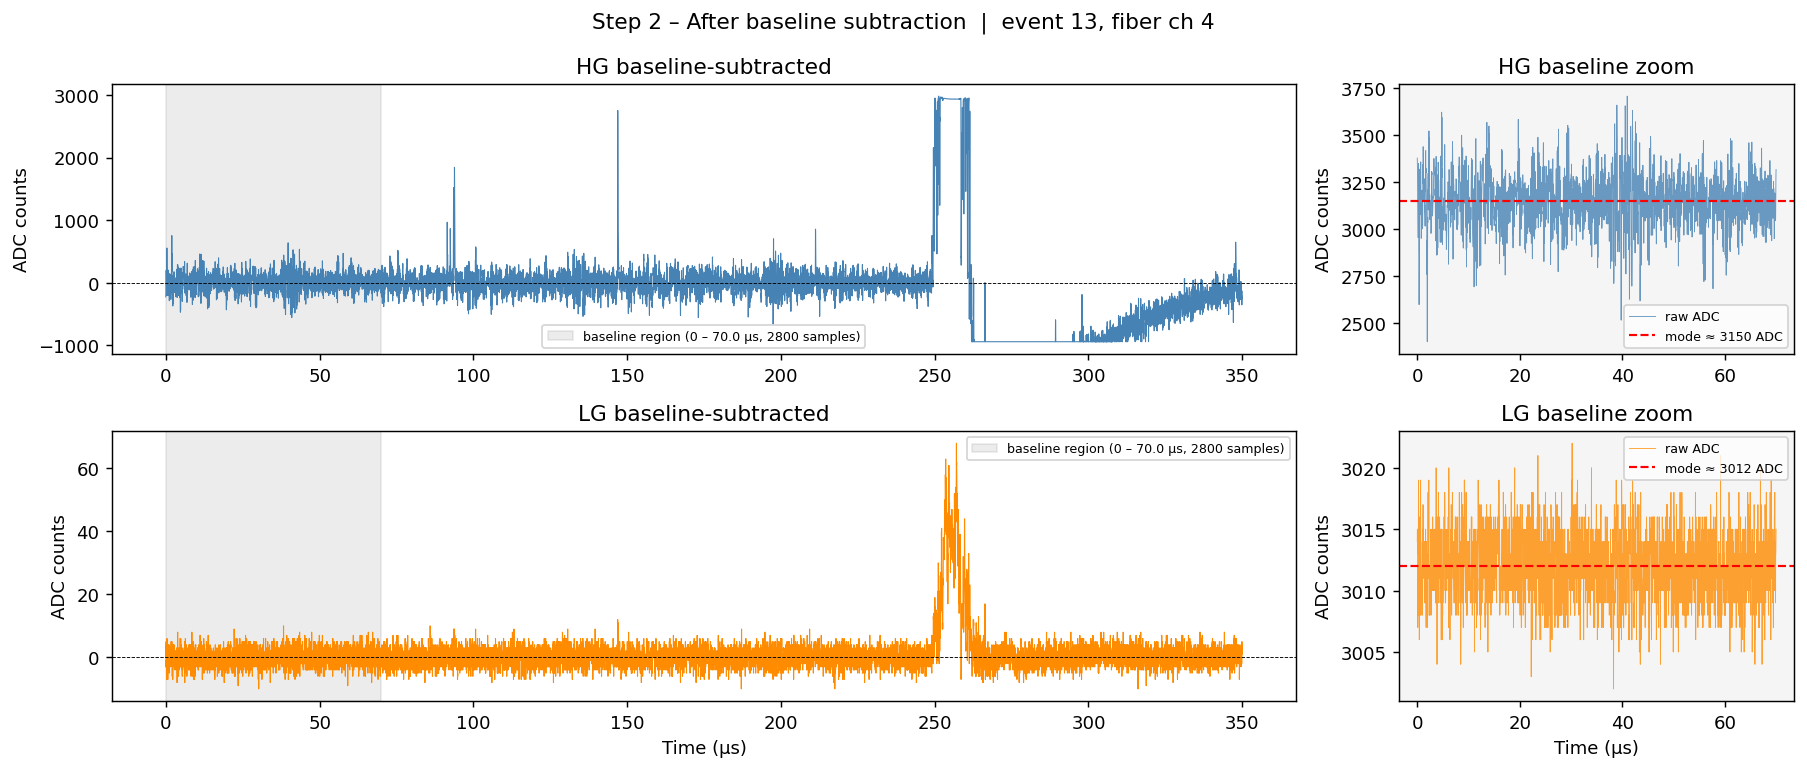

HG baseline (2800 samples, 0 – 70.0 µs): mean=3148.8  std=137.12  min=2398  max=3709 ADC
LG baseline (2800 samples, 0 – 70.0 µs): mean=3012.0  std=2.67  min=3002  max=3022 ADC


In [38]:
# Build the function exactly as irene.py does
subtract_baseline = baseline_subtractor(N_BASELINE)

# Apply to the full (n_fibers, n_samples) array for this event
bsfiber_hg = subtract_baseline(fiber_hg_raw)
bsfiber_lg = subtract_baseline(fiber_lg_raw)

baseline_end_us = N_BASELINE * FIBER_SAMP_WID * 1e-3  # µs

fig, axes = plt.subplots(2, 2, figsize=(14, 6),
                         gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle(f'Step 2 – After baseline subtraction  |  event {event_number}, fiber ch {FIBER_CH}')

for row, (raw, bs, color, gain) in enumerate([
        (fiber_hg_raw, bsfiber_hg, 'steelblue',  'HG'),
        (fiber_lg_raw, bsfiber_lg, 'darkorange',  'LG'),
]):
    # ── Left: full waveform after subtraction ─────────────────────────────
    ax = axes[row, 0]
    ax.plot(t_us, bs[FIBER_CH], lw=0.6, color=color)
    ax.axvspan(0, baseline_end_us, color='grey', alpha=0.15,
               label=f'baseline region (0 – {baseline_end_us:.1f} µs, {N_BASELINE} samples)')
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylabel('ADC counts')
    ax.set_title(f'{gain} baseline-subtracted')
    ax.legend(fontsize=7)
    if row == 1:
        ax.set_xlabel('Time (µs)')

    # ── Right: zoom into the baseline region on the RAW waveform ──────────
    ax_z = axes[row, 1]
    t_bl     = t_us[:N_BASELINE]
    raw_ch   = raw[FIBER_CH, :N_BASELINE].astype(float)
    # bs = -(raw - mode)  →  mode = raw + bs
    mode_val = (raw_ch + bs[FIBER_CH, :N_BASELINE]).mean()
    ax_z.plot(t_bl, raw_ch, lw=0.5, color=color, alpha=0.8, label='raw ADC')
    ax_z.axhline(mode_val, color='red', lw=1.2, ls='--',
                 label=f'mode ≈ {mode_val:.0f} ADC')
    ax_z.set_facecolor('#f5f5f5')
    ax_z.set_title(f'{gain} baseline zoom')
    ax_z.set_ylabel('ADC counts')
    ax_z.legend(fontsize=7)
    if row == 1:
        ax_z.set_xlabel('Time (µs)')

plt.tight_layout()
plt.show()

# Print baseline statistics
for raw, gain in [(fiber_hg_raw, 'HG'), (fiber_lg_raw, 'LG')]:
    bl = raw[FIBER_CH, :N_BASELINE].astype(float)
    print(f"{gain} baseline ({N_BASELINE} samples, 0 – {baseline_end_us:.1f} µs): "
          f"mean={bl.mean():.1f}  std={bl.std():.2f}  min={bl.min():.0f}  max={bl.max():.0f} ADC")


---
## Step 3 – Fourier low-pass filter
```python
# irene.py
bsfiber_hg_fft_filter = fl.map(fourier_filter(fiber_samp_wid, fiber_cutoff_freq_MHz),
                                args='bsfiber_hg', out='bsffiber_hg')
```
Zeroes all frequency components above `fiber_cutoff_freq_MHz` (3 MHz by default).
The right panel shows the frequency spectrum before and after filtering.

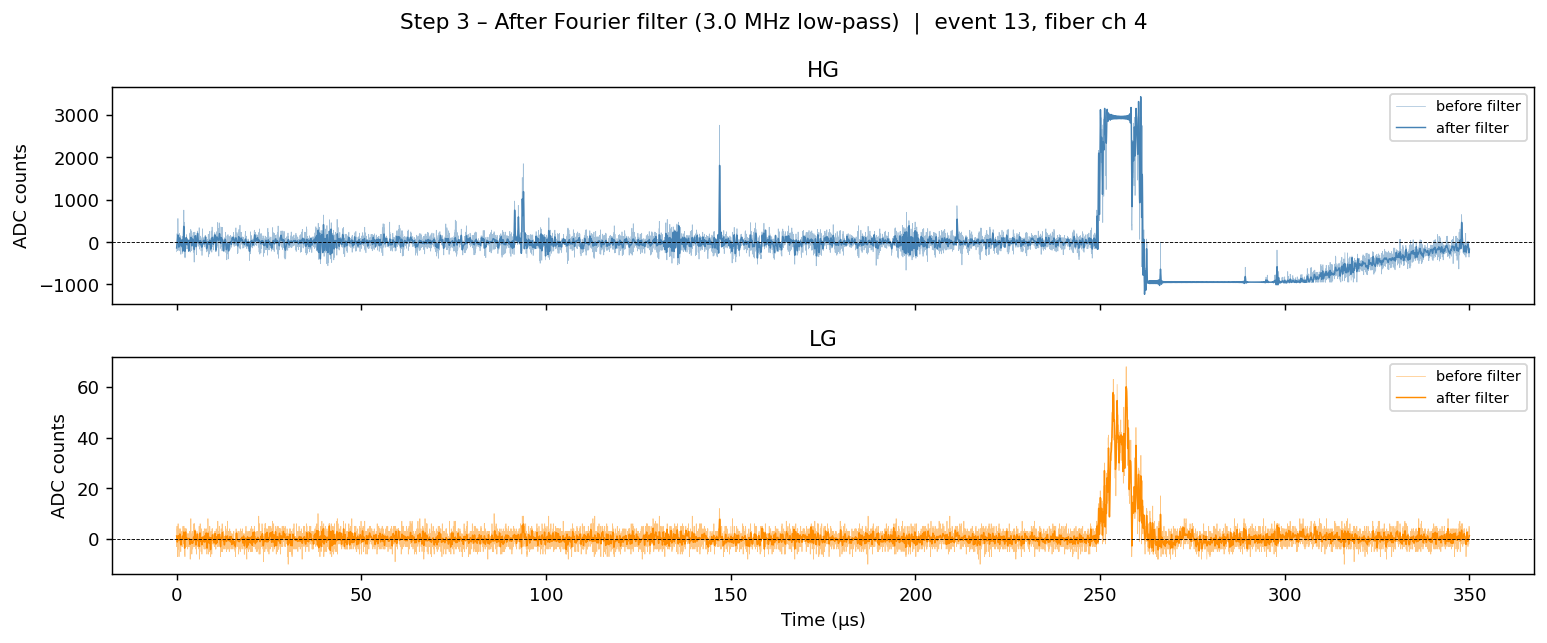

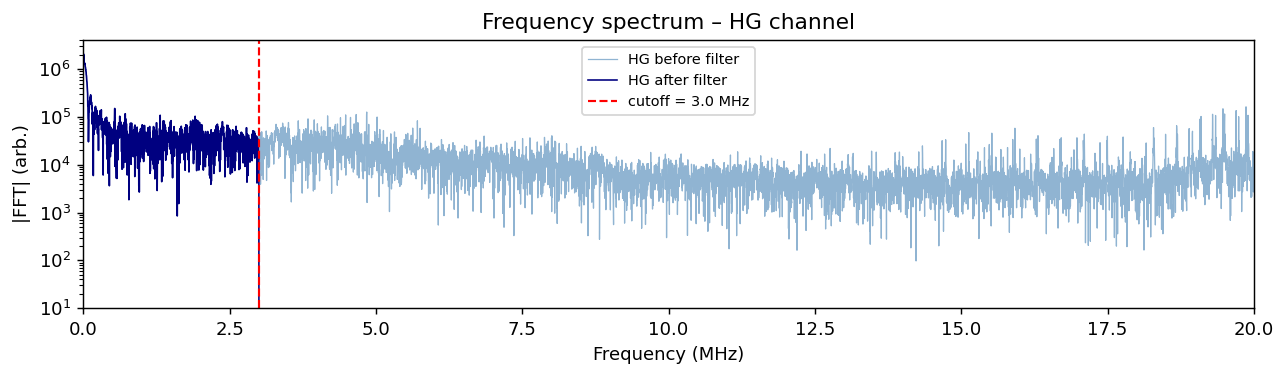

In [39]:
# Build the filter function exactly as irene.py does
apply_fourier_filter = fourier_filter(FIBER_SAMP_WID, FIBER_CUTOFF_FREQ_MHZ)

bsffiber_hg = apply_fourier_filter(bsfiber_hg)
bsffiber_lg = apply_fourier_filter(bsfiber_lg)

# ── Time domain ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
fig.suptitle(f'Step 3 – After Fourier filter ({FIBER_CUTOFF_FREQ_MHZ} MHz low-pass)  |  '
             f'event {event_number}, fiber ch {FIBER_CH}')

axes[0].plot(t_us, bsfiber_hg[FIBER_CH],  lw=0.4, color='steelblue', alpha=0.5, label='before filter')
axes[0].plot(t_us, bsffiber_hg[FIBER_CH], lw=0.8, color='steelblue', label='after filter')
axes[0].set_ylabel('ADC counts')
axes[0].set_title('HG')
axes[0].legend(fontsize=8)
axes[0].axhline(0, color='k', lw=0.5, ls='--')

axes[1].plot(t_us, bsfiber_lg[FIBER_CH],  lw=0.4, color='darkorange', alpha=0.5, label='before filter')
axes[1].plot(t_us, bsffiber_lg[FIBER_CH], lw=0.8, color='darkorange', label='after filter')
axes[1].set_ylabel('ADC counts')
axes[1].set_xlabel('Time (µs)')
axes[1].set_title('LG')
axes[1].legend(fontsize=8)
axes[1].axhline(0, color='k', lw=0.5, ls='--')

plt.tight_layout()
plt.show()

# ── Frequency domain ──────────────────────────────────────────────────────
freqs_MHz = np.fft.rfftfreq(n_samples, d=FIBER_SAMP_WID) * 1e3  # ns^-1 → MHz

spec_before = np.abs(np.fft.rfft(bsfiber_hg[FIBER_CH]))
spec_after  = np.abs(np.fft.rfft(bsffiber_hg[FIBER_CH]))

fig, ax = plt.subplots(figsize=(10, 3))
ax.semilogy(freqs_MHz, spec_before, lw=0.7, color='steelblue', alpha=0.6, label='HG before filter')
ax.semilogy(freqs_MHz, spec_after + 1e-6, lw=0.9, color='navy', label='HG after filter')
ax.axvline(FIBER_CUTOFF_FREQ_MHZ, color='red', ls='--', lw=1.2, label=f'cutoff = {FIBER_CUTOFF_FREQ_MHZ} MHz')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('|FFT| (arb.)')
ax.set_title('Frequency spectrum – HG channel')
ax.legend(fontsize=8)
ax.set_xlim(0, min(50, freqs_MHz.max()))
ax.set_ylim(1e1, spec_before.max() * 2)
plt.tight_layout()
plt.show()

---
## Step 4 – Calibration (ADC → photo-electrons) and MAW
```python
# irene.py
bswf_hg_to_cbswf = fl.map(calibrate_fibers_hg(detector_db, run_number, n_maw_s1),
                           args='bsffiber_hg', out=('cbsfiber_hg_maw', 'cbsfiber_hg_sum_maw'))
bswf_lg_to_cbswf = fl.map(calibrate_fibers_lg(detector_db, run_number, n_maw_s2),
                           args='bsffiber_lg', out=('cbsfiber_lg_maw', 'cbsfiber_lg_sum_maw'))
```
Each function divides by `adc_to_pes`, applies an MAW (moving-average window), then sums over all channels to produce a single summed waveform.
For LG an additional per-channel `amplification` factor is applied.

In [54]:
from invisible_cities.database import load_db

# Read calibration constants used by the fiber calibration step
datafiber = load_db.DataFiber(DETECTOR_DB, RUN_NUMBER)
adc_to_pes_db = np.abs(datafiber.adc_to_pes.values)
amplification_db = np.abs(datafiber.amplification.values)

print('adc_to_pes (DB values):')
print(adc_to_pes_db)
print('\namplification (DB values):')
print(amplification_db)


adc_to_pes (DB values):
[161.41641108 148.49223031 125.14407162 180.37699754 134.71467681
 163.05995862 173.55011389 171.69994277 169.99278689 169.82946387
 175.8655052  172.71020513 136.62427314 146.8833403  148.31501118
 150.46643126 186.66364984 160.0534799  156.72181901 153.63241316
 157.58933514 162.03491512 155.54744104 152.36655412 134.66818746
 132.99125954 138.53901979 133.87469358 148.54101359 139.64180098
 121.42046439 114.68506026 168.51427112 164.66649355 128.01460237
 139.59038392]

amplification (DB values):
[322.43500574 202.89788727 338.19610575 325.71567943 196.66621598
 231.6008878  203.85371257 247.51245099 347.69628592 399.51223688
 189.60455781 275.08010906 237.06722801 201.21290991 313.9030179
   1.         830.98424298 380.0866367  244.08269603 218.48591213
 228.57806097 425.63223147 397.08912035 386.30087969 359.09674486
 263.61860053 200.13989223 316.9316629  271.87096527 265.85024065
 327.95205504 211.08439027 365.03283533 400.36568807 227.02555641
 208.13306

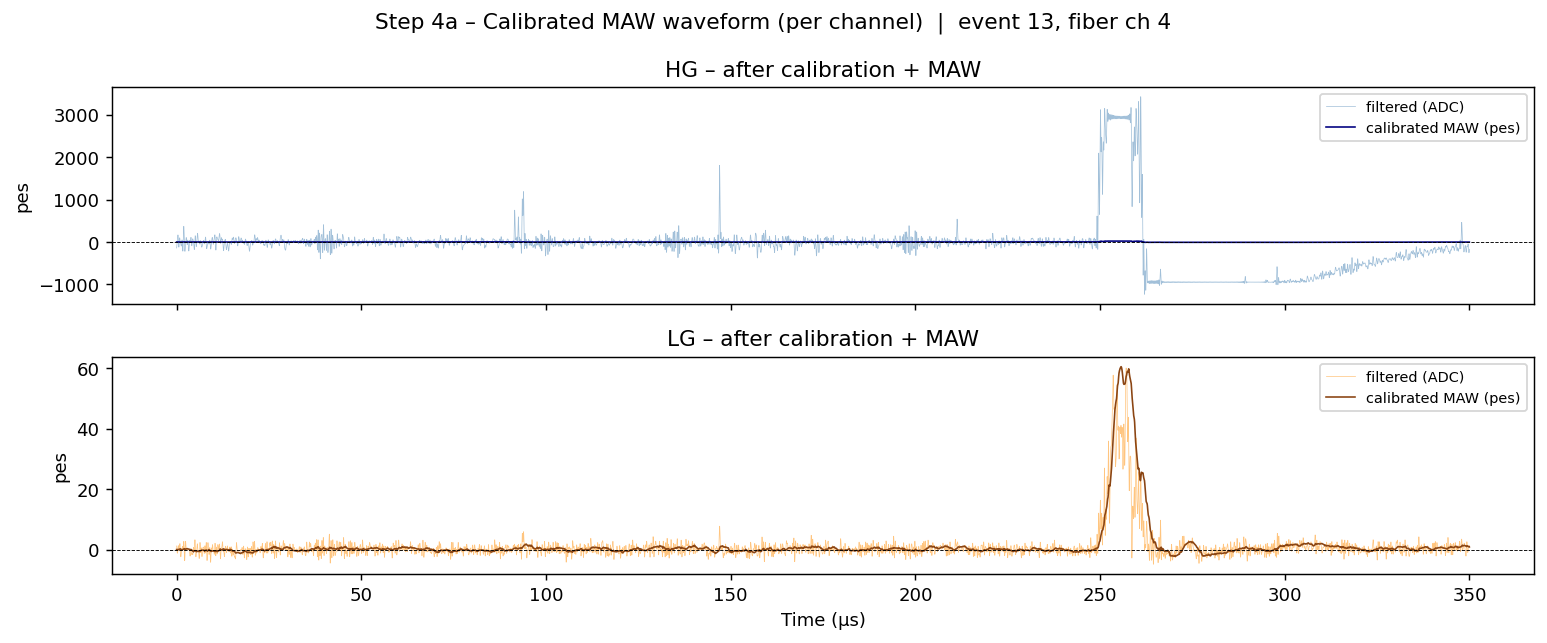

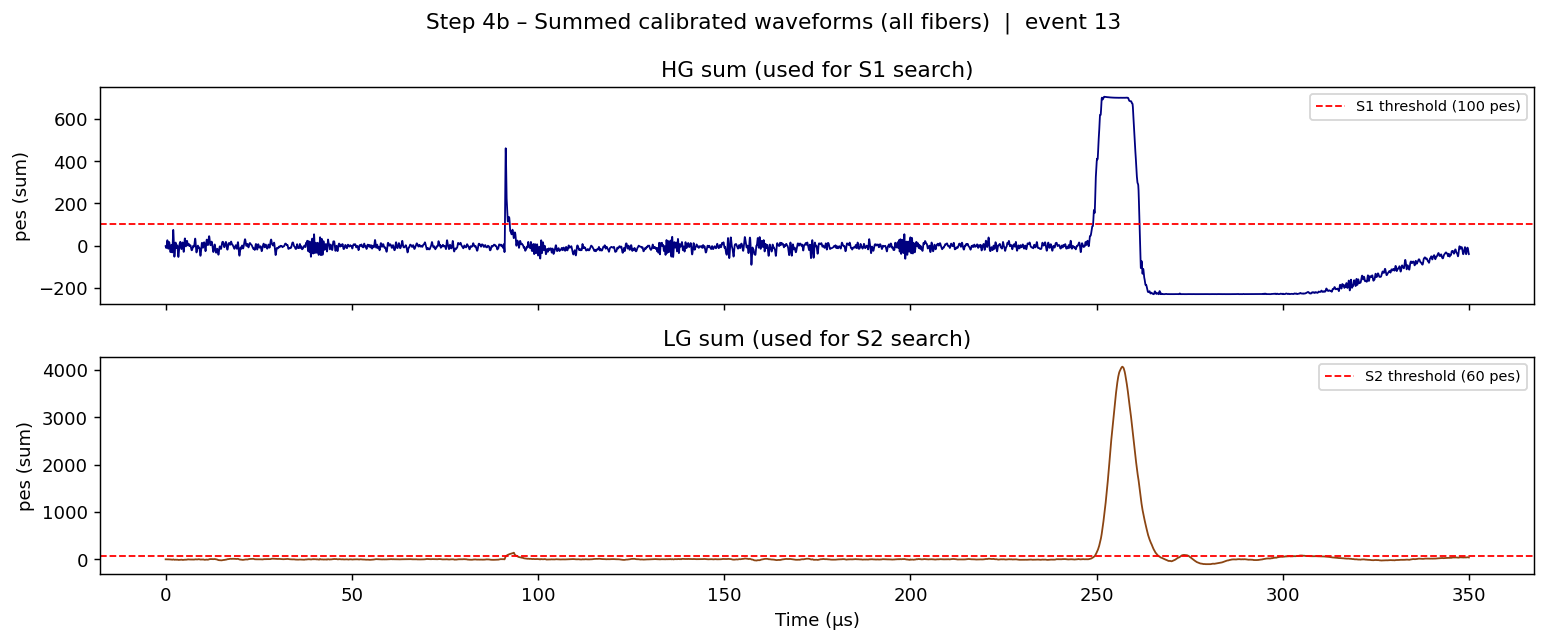

In [55]:
# Build calibration functions exactly as irene.py does
cal_hg = calibrate_fibers_hg(DETECTOR_DB, RUN_NUMBER, N_MAW_S1)
cal_lg = calibrate_fibers_lg(DETECTOR_DB, RUN_NUMBER, N_MAW_S2)

cbsfiber_hg_maw, cbsfiber_hg_sum_maw = cal_hg(bsffiber_hg)
cbsfiber_lg_maw, cbsfiber_lg_sum_maw = cal_lg(bsffiber_lg)

# ── Per-channel calibrated waveform ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
fig.suptitle(f'Step 4a – Calibrated MAW waveform (per channel)  |  '
             f'event {event_number}, fiber ch {FIBER_CH}')

axes[0].plot(t_us, bsffiber_hg[FIBER_CH],    lw=0.4, color='steelblue', alpha=0.5, label='filtered (ADC)')
axes[0].plot(t_us, cbsfiber_hg_maw[FIBER_CH], lw=0.9, color='navy',      label='calibrated MAW (pes)')
axes[0].set_ylabel('pes')
axes[0].set_title('HG – after calibration + MAW')
axes[0].legend(fontsize=8)
axes[0].axhline(0, color='k', lw=0.5, ls='--')

axes[1].plot(t_us, bsffiber_lg[FIBER_CH],    lw=0.4, color='darkorange', alpha=0.5, label='filtered (ADC)')
axes[1].plot(t_us, cbsfiber_lg_maw[FIBER_CH], lw=0.9, color='saddlebrown', label='calibrated MAW (pes)')
axes[1].set_ylabel('pes')
axes[1].set_xlabel('Time (µs)')
axes[1].set_title('LG – after calibration + MAW')
axes[1].legend(fontsize=8)
axes[1].axhline(0, color='k', lw=0.5, ls='--')

plt.tight_layout()
plt.show()

# ── Summed waveforms (all channels) ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
fig.suptitle(f'Step 4b – Summed calibrated waveforms (all fibers)  |  event {event_number}')

axes[0].plot(t_us, cbsfiber_hg_sum_maw, lw=1.0, color='navy')
axes[0].axhline(THR_CSUM_S1, color='red', ls='--', lw=1.0, label=f'S1 threshold ({THR_CSUM_S1:.0f} pes)')
axes[0].set_ylabel('pes (sum)')
axes[0].set_title('HG sum (used for S1 search)')
axes[0].legend(fontsize=8)

axes[1].plot(t_us, cbsfiber_lg_sum_maw, lw=1.0, color='saddlebrown')
axes[1].axhline(THR_CSUM_S2, color='red', ls='--', lw=1.0, label=f'S2 threshold ({THR_CSUM_S2:.0f} pes)')
axes[1].set_ylabel('pes (sum)')
axes[1].set_xlabel('Time (µs)')
axes[1].set_title('LG sum (used for S2 search)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Step 5 – Zero suppression (S1 / S2 index finding)
```python
# irene.py
fiber_hg_zero_suppress = fl.map(zero_suppress_wfs_hg(thr_csum_s1),
                                 args='cbsfiber_hg_sum_maw', out='s1_indices')
fiber_lg_zero_suppress = fl.map(zero_suppress_wfs_lg(thr_csum_s2),
                                 args='cbsfiber_lg_sum_maw', out=('s2_indices', 's2_energies'))
```
Samples above threshold are kept as **S1** (HG) or **S2** (LG) candidate indices.
The coloured bands show which time bins survive the cut.

In [41]:
# Build zero-suppression functions exactly as irene.py does
zs_hg = zero_suppress_wfs_hg(THR_CSUM_S1)
zs_lg = zero_suppress_wfs_lg(THR_CSUM_S2)

s1_indices             = zs_hg(cbsfiber_hg_sum_maw)
s2_indices, s2_energies = zs_lg(cbsfiber_lg_sum_maw)

print(f"S1 indices (HG above {THR_CSUM_S1:.0f} pes): {len(s1_indices)} samples")
if len(s1_indices):
    print(f"  time range: {t_us[s1_indices[0]]:.3f} – {t_us[s1_indices[-1]]:.3f} µs")

print(f"S2 indices (LG above {THR_CSUM_S2:.0f} pes): {len(s2_indices)} samples")
if len(s2_indices):
    print(f"  time range: {t_us[s2_indices[0]]:.3f} – {t_us[s2_indices[-1]]:.3f} µs")

S1 indices (HG above 100 pes): 551 samples
  time range: 91.125 – 261.525 µs
S2 indices (LG above 60 pes): 1340 samples
  time range: 91.325 – 311.150 µs


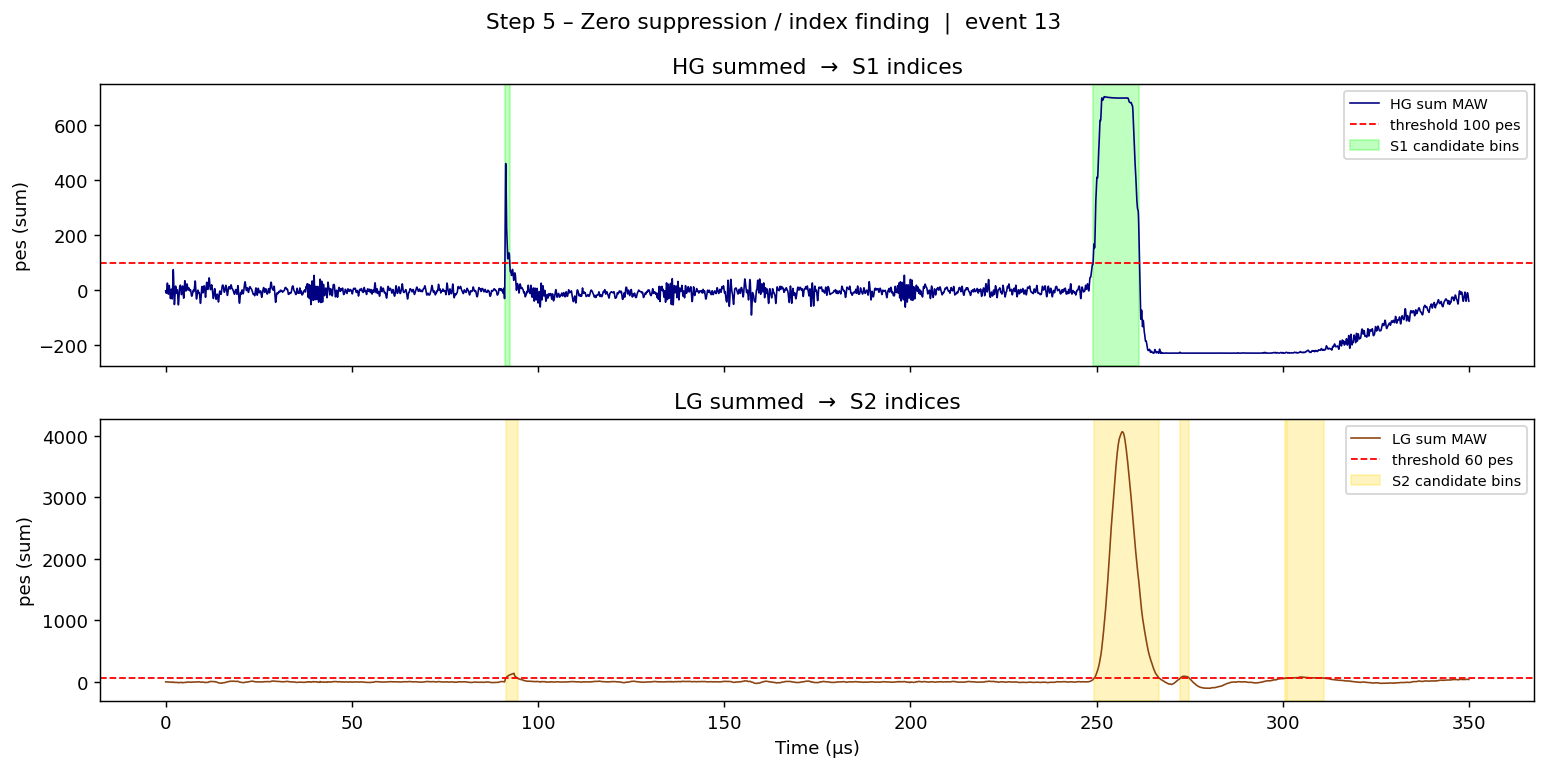

In [42]:
def highlight_indices(ax, indices, t_us, color, alpha=0.25, label=None):
    """Shade contiguous blocks of indices on an existing axes."""
    if len(indices) == 0:
        return
    # Find contiguous runs
    breaks = np.where(np.diff(indices) > 1)[0] + 1
    segments = np.split(indices, breaks)
    first = True
    for seg in segments:
        ax.axvspan(t_us[seg[0]], t_us[seg[-1]],
                   color=color, alpha=alpha,
                   label=label if first else None)
        first = False


fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle(f'Step 5 – Zero suppression / index finding  |  event {event_number}')

# HG sum with S1 bands
axes[0].plot(t_us, cbsfiber_hg_sum_maw, lw=0.9, color='navy', label='HG sum MAW')
axes[0].axhline(THR_CSUM_S1, color='red', ls='--', lw=1.0, label=f'threshold {THR_CSUM_S1:.0f} pes')
highlight_indices(axes[0], s1_indices, t_us, color='lime', label='S1 candidate bins')
axes[0].set_ylabel('pes (sum)')
axes[0].set_title('HG summed  →  S1 indices')
axes[0].legend(fontsize=8)

# LG sum with S2 bands
axes[1].plot(t_us, cbsfiber_lg_sum_maw, lw=0.9, color='saddlebrown', label='LG sum MAW')
axes[1].axhline(THR_CSUM_S2, color='red', ls='--', lw=1.0, label=f'threshold {THR_CSUM_S2:.0f} pes')
highlight_indices(axes[1], s2_indices, t_us, color='gold', label='S2 candidate bins')
axes[1].set_ylabel('pes (sum)')
axes[1].set_xlabel('Time (µs)')
axes[1].set_title('LG summed  →  S2 indices')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Summary – All stages side-by-side
One quick overview of the HG waveform for channel `FIBER_CH` as it evolves through the pipeline.

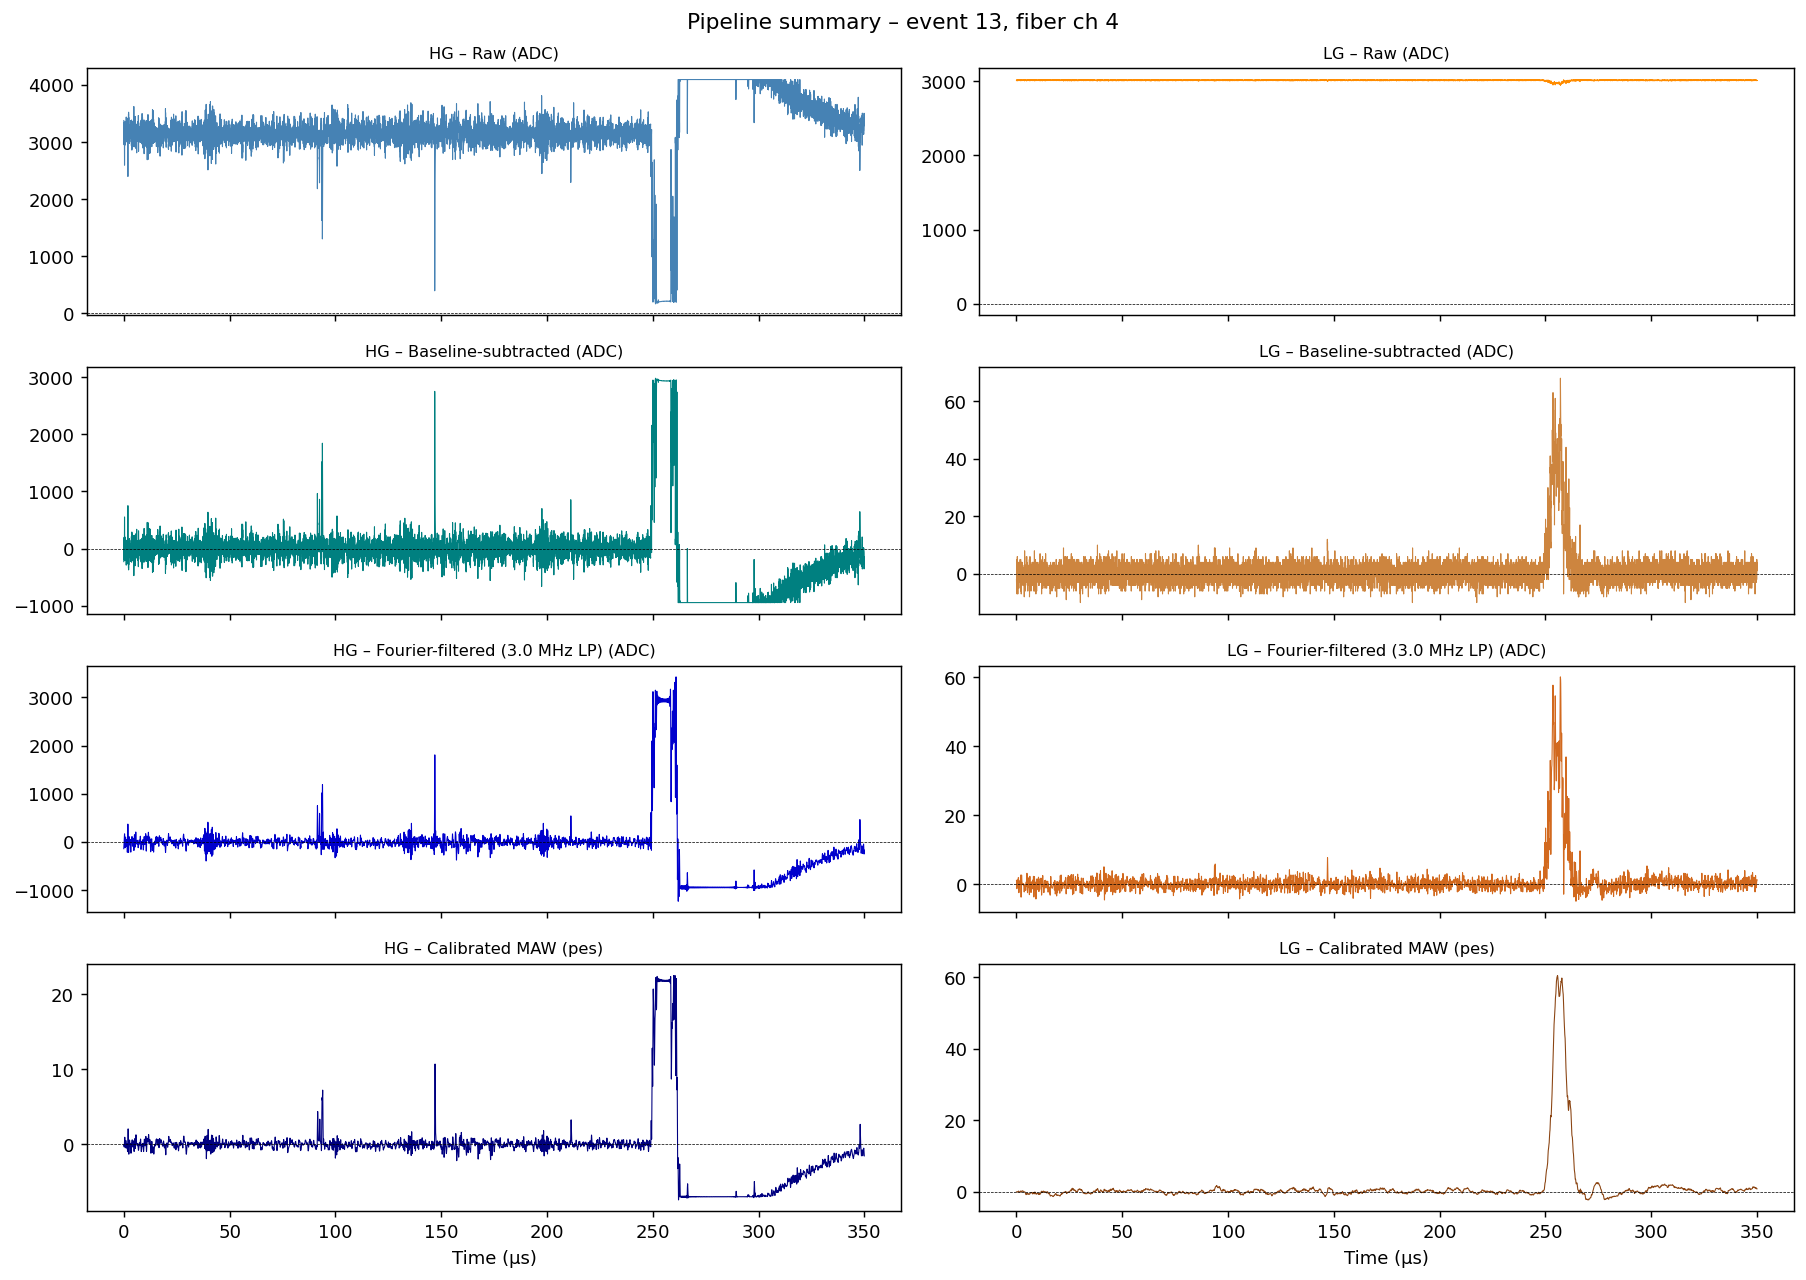

In [43]:
stages_hg = [
    (fiber_hg_raw[FIBER_CH],      'Raw (ADC)',                'steelblue'),
    (bsfiber_hg[FIBER_CH],        'Baseline-subtracted (ADC)', 'teal'),
    (bsffiber_hg[FIBER_CH],       f'Fourier-filtered ({FIBER_CUTOFF_FREQ_MHZ} MHz LP) (ADC)', 'mediumblue'),
    (cbsfiber_hg_maw[FIBER_CH],   'Calibrated MAW (pes)',      'navy'),
]

stages_lg = [
    (fiber_lg_raw[FIBER_CH],      'Raw (ADC)',                 'darkorange'),
    (bsfiber_lg[FIBER_CH],        'Baseline-subtracted (ADC)', 'peru'),
    (bsffiber_lg[FIBER_CH],       f'Fourier-filtered ({FIBER_CUTOFF_FREQ_MHZ} MHz LP) (ADC)', 'chocolate'),
    (cbsfiber_lg_maw[FIBER_CH],   'Calibrated MAW (pes)',       'saddlebrown'),
]

fig, axes = plt.subplots(len(stages_hg), 2, figsize=(14, 10), sharex=True)
fig.suptitle(f'Pipeline summary – event {event_number}, fiber ch {FIBER_CH}', fontsize=12)

for i, ((wf_hg, lbl_hg, col_hg), (wf_lg, lbl_lg, col_lg)) in enumerate(zip(stages_hg, stages_lg)):
    axes[i, 0].plot(t_us, wf_hg, lw=0.6, color=col_hg)
    axes[i, 0].set_title(f'HG – {lbl_hg}', fontsize=9)
    axes[i, 0].axhline(0, color='k', lw=0.4, ls='--')

    axes[i, 1].plot(t_us, wf_lg, lw=0.6, color=col_lg)
    axes[i, 1].set_title(f'LG – {lbl_lg}', fontsize=9)
    axes[i, 1].axhline(0, color='k', lw=0.4, ls='--')

for ax in axes[-1, :]:
    ax.set_xlabel('Time (µs)')

plt.tight_layout()
plt.show()

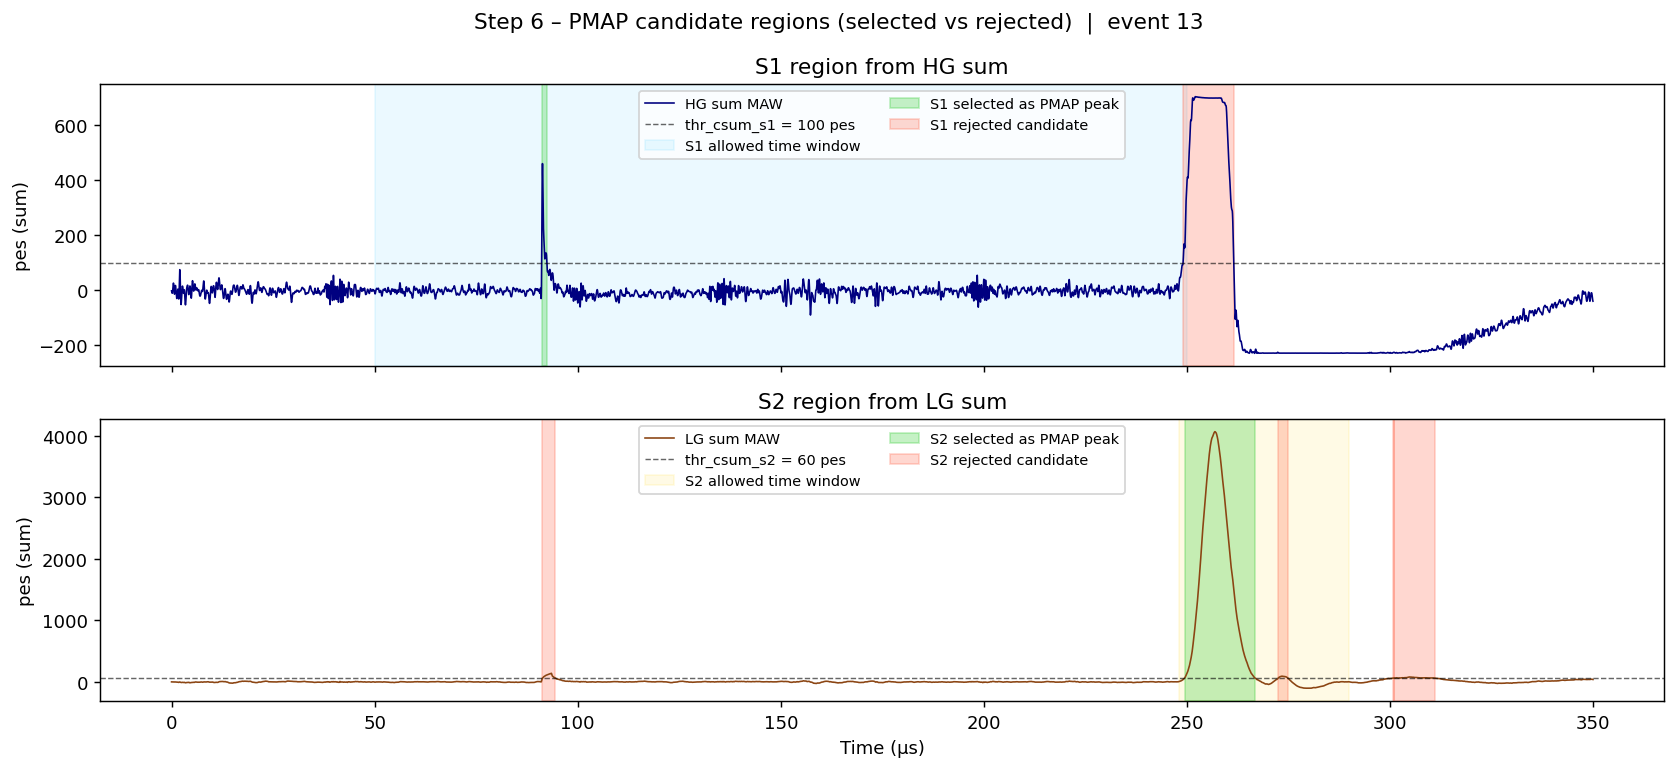

=== Stage A: Candidate split + time/length selection ===
S1 candidates: 2 | selected: 1 | rejected: 1
  S1 01:   91.125-  92.425 µs | width=  52 bins | SELECTED
  S1 02:  249.075- 261.550 µs | width= 499 bins | REJECTED
         - ends after tmax (261.550 > 250.000 µs)
         - length out of range (499 not in [1, 100] bins)
S2 candidates: 5 | selected: 1 | rejected: 4
  S2 01:   91.325-  94.525 µs | width= 128 bins | REJECTED
         - starts before tmin (91.325 < 248.000 µs)
         - length out of range (128 not in [150, 100000] bins)
  S2 02:  249.425- 266.875 µs | width= 698 bins | SELECTED
  S2 03:  272.475- 274.925 µs | width=  98 bins | REJECTED
         - length out of range (98 not in [150, 100000] bins)
  S2 04:  300.675- 300.925 µs | width=  10 bins | REJECTED
         - ends after tmax (300.925 > 290.000 µs)
         - length out of range (10 not in [150, 100000] bins)
  S2 05:  301.025- 311.175 µs | width= 406 bins | REJECTED
         - ends after tmax (311.175 > 290.0

In [51]:
# --- Step 6: PMAP creation and detailed selection diagnostics (S1/S2) ---
# Reproduce Irene's S1/S2 peak-finding stage and explain why peaks/events are selected or rejected.

from invisible_cities.reco import peak_functions as pkf
from invisible_cities.types.ic_types import minmax
from invisible_cities.core import system_of_units as units
from invisible_cities.cities.components import build_pmap_dual_gain
from invisible_cities.filters.s1s2_filter import S12Selector, pmap_filter

# PMAP search parameters (matching irene.conf)
S1_TMIN_US, S1_TMAX_US = 50.0, 250.0
S1_STRIDE              = 3
S1_LMIN, S1_LMAX       = 1, 100
S1_REBIN_STRIDE        = 1

S2_TMIN_US, S2_TMAX_US = 248.0, 290.0
S2_STRIDE              = 2
S2_LMIN, S2_LMAX       = 150, 100000
S2_REBIN_STRIDE        = 40

THR_SIPM_S2            = 1.5  # pes
PMT_SAMP_WID           = 25 * units.ns
SIPM_SAMP_WID          = 1  * units.mus

# Downstream selector parameters (matching s12_selector.conf)
selector_pars = dict(
    s1_nmin=1, s1_nmax=1,
    s1_emin=0.0, s1_emax=1e6,
    s1_wmin=100 * units.ns, s1_wmax=500 * units.ns,
    s1_hmin=0.0, s1_hmax=1e6,
    s1_ethr=0.5,
    s2_nmin=1, s2_nmax=10,
    s2_emin=0.0, s2_emax=1e6,
    s2_wmin=3 * units.mus, s2_wmax=10 * units.ms,
    s2_hmin=0.0, s2_hmax=1e6,
    s2_nsipmmin=1, s2_nsipmmax=100,
    s2_ethr=1.0,
)


def classify_candidate_peaks(indices, stride, tmin_us, tmax_us, lmin, lmax):
    """Split thresholded indices into candidates and classify by Irene time/length cuts."""
    candidates = pkf.split_in_peaks(indices, stride)

    selected = pkf.select_peaks(candidates,
                                time=minmax(tmin_us * units.mus, tmax_us * units.mus),
                                length=minmax(lmin, lmax),
                                pmt_samp_wid=PMT_SAMP_WID)

    selected_keys = {tuple(pk.tolist()) for pk in selected}
    selected_out  = []
    rejected_out  = []

    for pk in candidates:
        key = tuple(pk.tolist())
        bucket = selected_out if key in selected_keys else rejected_out
        bucket.append(pk)

    return candidates, selected_out, rejected_out


def candidate_reason(pk, tmin_us, tmax_us, lmin, lmax):
    """Explain why a thresholded region passes/fails PMAP candidate cuts."""
    t0 = t_us[pk[0]]
    t1 = t_us[pk[-1]] + FIBER_SAMP_WID * 1e-3
    width_bins = pk[-1] + 1 - pk[0]

    start_ok = t0 >= tmin_us
    end_ok   = t1 <= tmax_us
    len_ok   = (width_bins >= lmin) and (width_bins <= lmax)

    reasons = []
    if not start_ok:
        reasons.append(f"starts before tmin ({t0:.3f} < {tmin_us:.3f} µs)")
    if not end_ok:
        reasons.append(f"ends after tmax ({t1:.3f} > {tmax_us:.3f} µs)")
    if not len_ok:
        reasons.append(f"length out of range ({width_bins} not in [{lmin}, {lmax}] bins)")

    return dict(t0=t0, t1=t1, width_bins=width_bins,
                passed=(start_ok and end_ok and len_ok), reasons=reasons)


def peak_selector_diagnostics(peak, kind, pars):
    """Compute per-peak selector variables and pass/fail flags."""
    if kind == 'S1':
        ethr = pars['s1_ethr']
        e_rng = minmax(pars['s1_emin'], pars['s1_emax'])
        w_rng = minmax(pars['s1_wmin'], pars['s1_wmax'])
        h_rng = minmax(pars['s1_hmin'], pars['s1_hmax'])
        nsi_rng = None
    else:
        ethr = pars['s2_ethr']
        e_rng = minmax(pars['s2_emin'], pars['s2_emax'])
        w_rng = minmax(pars['s2_wmin'], pars['s2_wmax'])
        h_rng = minmax(pars['s2_hmin'], pars['s2_hmax'])
        nsi_rng = minmax(pars['s2_nsipmmin'], pars['s2_nsipmmax'])

    e_val = peak.energy_above_threshold(ethr)
    w_val = peak.width_above_threshold(ethr)
    h_val = peak.height
    nsi_val = peak.sipms.ids.size

    e_ok = e_rng.contains(e_val)
    w_ok = w_rng.contains(w_val)
    h_ok = h_rng.contains(h_val)
    nsi_ok = True if nsi_rng is None else nsi_rng.contains(nsi_val)

    return dict(
        e_val=e_val, w_val=w_val, h_val=h_val, nsi_val=nsi_val,
        e_ok=e_ok, w_ok=w_ok, h_ok=h_ok, nsi_ok=nsi_ok,
        passed=(e_ok and w_ok and h_ok and nsi_ok),
        ethr=ethr,
    )


# 1) Candidate regions from zero-suppression indices
s1_candidates, s1_selected, s1_rejected = classify_candidate_peaks(
    s1_indices, S1_STRIDE, S1_TMIN_US, S1_TMAX_US, S1_LMIN, S1_LMAX)

s2_candidates, s2_selected, s2_rejected = classify_candidate_peaks(
    s2_indices, S2_STRIDE, S2_TMIN_US, S2_TMAX_US, S2_LMIN, S2_LMAX)

# 2) Build PMAP from dual-gain PMT information (S1 from HG, S2 from LG)
# Note: SiPM channel mapping in this demo file differs from DB shape, so we pass sipmzs=None here.
pmap_builder = build_pmap_dual_gain(
    DETECTOR_DB, RUN_NUMBER,
    PMT_SAMP_WID, SIPM_SAMP_WID,
    S1_LMAX, S1_LMIN, S1_REBIN_STRIDE, S1_STRIDE, S1_TMAX_US * units.mus, S1_TMIN_US * units.mus,
    S2_LMAX, S2_LMIN, S2_REBIN_STRIDE, S2_STRIDE, S2_TMAX_US * units.mus, S2_TMIN_US * units.mus,
    THR_SIPM_S2)

pmap_evt = pmap_builder(cbsfiber_hg_maw, cbsfiber_lg_maw, s1_indices, s2_indices, None)

# 3) Visualise accepted/rejected PMAP candidate regions
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig.suptitle(f'Step 6 – PMAP candidate regions (selected vs rejected)  |  event {event_number}')

# S1 (HG sum)
ax = axes[0]
ax.plot(t_us, cbsfiber_hg_sum_maw, lw=0.9, color='navy', label='HG sum MAW')
ax.axhline(THR_CSUM_S1, color='k', ls='--', lw=0.8, alpha=0.6, label=f'thr_csum_s1 = {THR_CSUM_S1:.0f} pes')
ax.axvspan(S1_TMIN_US, S1_TMAX_US, color='deepskyblue', alpha=0.08, label='S1 allowed time window')

for i, pk in enumerate(s1_selected):
    t0 = t_us[pk[0]]
    t1 = t_us[pk[-1]] + FIBER_SAMP_WID * 1e-3
    ax.axvspan(t0, t1, color='limegreen', alpha=0.28,
               label='S1 selected as PMAP peak' if i == 0 else None)

for i, pk in enumerate(s1_rejected):
    t0 = t_us[pk[0]]
    t1 = t_us[pk[-1]] + FIBER_SAMP_WID * 1e-3
    ax.axvspan(t0, t1, color='tomato', alpha=0.25,
               label='S1 rejected candidate' if i == 0 else None)

ax.set_ylabel('pes (sum)')
ax.set_title('S1 region from HG sum')
ax.legend(fontsize=8, ncol=2)

# S2 (LG sum)
ax = axes[1]
ax.plot(t_us, cbsfiber_lg_sum_maw, lw=0.9, color='saddlebrown', label='LG sum MAW')
ax.axhline(THR_CSUM_S2, color='k', ls='--', lw=0.8, alpha=0.6, label=f'thr_csum_s2 = {THR_CSUM_S2:.0f} pes')
ax.axvspan(S2_TMIN_US, S2_TMAX_US, color='gold', alpha=0.10, label='S2 allowed time window')

for i, pk in enumerate(s2_selected):
    t0 = t_us[pk[0]]
    t1 = t_us[pk[-1]] + FIBER_SAMP_WID * 1e-3
    ax.axvspan(t0, t1, color='limegreen', alpha=0.28,
               label='S2 selected as PMAP peak' if i == 0 else None)

for i, pk in enumerate(s2_rejected):
    t0 = t_us[pk[0]]
    t1 = t_us[pk[-1]] + FIBER_SAMP_WID * 1e-3
    ax.axvspan(t0, t1, color='tomato', alpha=0.25,
               label='S2 rejected candidate' if i == 0 else None)

ax.set_ylabel('pes (sum)')
ax.set_xlabel('Time (µs)')
ax.set_title('S2 region from LG sum')
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# 4) Detailed diagnostics for PMAP-candidate selection (time/length stage)
print('=== Stage A: Candidate split + time/length selection ===')
print(f'S1 candidates: {len(s1_candidates)} | selected: {len(s1_selected)} | rejected: {len(s1_rejected)}')
for i, pk in enumerate(s1_candidates, 1):
    info = candidate_reason(pk, S1_TMIN_US, S1_TMAX_US, S1_LMIN, S1_LMAX)
    if info['passed']:
        print(f"  S1 {i:02d}: {info['t0']:8.3f}-{info['t1']:8.3f} µs | width={info['width_bins']:4d} bins | SELECTED")
    else:
        print(f"  S1 {i:02d}: {info['t0']:8.3f}-{info['t1']:8.3f} µs | width={info['width_bins']:4d} bins | REJECTED")
        for r in info['reasons']:
            print(f"         - {r}")

print(f'S2 candidates: {len(s2_candidates)} | selected: {len(s2_selected)} | rejected: {len(s2_rejected)}')
for i, pk in enumerate(s2_candidates, 1):
    info = candidate_reason(pk, S2_TMIN_US, S2_TMAX_US, S2_LMIN, S2_LMAX)
    if info['passed']:
        print(f"  S2 {i:02d}: {info['t0']:8.3f}-{info['t1']:8.3f} µs | width={info['width_bins']:4d} bins | SELECTED")
    else:
        print(f"  S2 {i:02d}: {info['t0']:8.3f}-{info['t1']:8.3f} µs | width={info['width_bins']:4d} bins | REJECTED")
        for r in info['reasons']:
            print(f"         - {r}")

print('\nPMAP object built:')
print(f'  nS1 in pmap = {len(pmap_evt.s1s)}')
print(f'  nS2 in pmap = {len(pmap_evt.s2s)}')